In [391]:
# load the necessary functions
# for (fnm in list.files("/home/jovyan/shared_materials/rwwa", full.names = T)) source(fnm)

# import R libraries from WWA
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import pandas2ri
from rpy2.robjects.vectors import ListVector
from c3s_event_attribution_tools import Utils

ro.r('''if (!requireNamespace("devtools", quietly = TRUE)) {install.packages("devtools", repos="https://cloud.r-project.org", quiet=TRUE)}''')
ro.r('devtools::install_github("WorldWeatherAttribution/rwwa")')
rwwa = importr("rwwa")
%load_ext rpy2.ipython

# print(ro.r('.libPaths()'))

R callback write-console: Using GitHub PAT from the git credential store.
  
R callback write-console: Skipping install of 'rwwa' from a github remote, the SHA1 (236d9a6b) has not changed since last install.
  Use `force = TRUE` to force installation
  


The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [392]:
your_save_directory = Utils.get_save_directory(dir="../data")

In [393]:
%%R
library(rwwa)

# Synthesise results from observations and climate models

In [394]:
%%R -i your_save_directory

observations_path <- file.path(your_save_directory, "res-obs_era5.csv")

# load the observational results
df_obs <- read.csv(observations_path, row.names = "X")

In [395]:
%%R
knitr::kable(df_obs)



|     |  mu0_est| mu0_lower| mu0_upper| sigma0_est| sigma0_lower| sigma0_upper| alpha_gmst_est| alpha_gmst_lower| alpha_gmst_upper| shape_est| shape_lower| shape_upper|  disp_est| disp_lower| disp_upper| event_magnitude_est| event_magnitude_lower| event_magnitude_upper| return_period_est| return_period_lower| return_period_upper|   PR_est|  PR_lower| PR_upper| dI_abs_est| dI_abs_lower| dI_abs_upper| dI_rel_est| dI_rel_lower| dI_rel_upper|  aic_est| aic_lower| aic_upper| n_est| n_lower| n_upper|
|:----|--------:|---------:|---------:|----------:|------------:|------------:|--------------:|----------------:|----------------:|---------:|-----------:|-----------:|---------:|----------:|----------:|-------------------:|---------------------:|---------------------:|-----------------:|-------------------:|-------------------:|--------:|---------:|--------:|----------:|------------:|------------:|----------:|------------:|------------:|--------:|---------:|---------:|-----:|-------:|-------:

In [396]:
%%R

models_path = file.path(your_save_directory, "res-models-Future-2.6.csv")

# load the climate model results
df_models <- read.csv(models_path, row.names = "X")

In [397]:
%%R
knitr::kable(df_models)



|                                    |Include | eval_sigma0_est| eval_sigma0_lower| eval_sigma0_upper| eval_shape_est| eval_shape_lower| eval_shape_upper| rp_value| attr_PR_est| attr_PR_lower| attr_PR_upper| attr_dI.abs_est| attr_dI.abs_lower| attr_dI.abs_upper| attr_dI.rel_est| attr_dI.rel_lower| attr_dI.rel_upper| proj_PR_est| proj_PR_lower| proj_PR_upper| proj_dI.abs_est| proj_dI.abs_lower| proj_dI.abs_upper| proj_dI.rel_est| proj_dI.rel_lower| proj_dI.rel_upper| aic_eval| aic_attr| aic_proj| attr_nobs| attr_nsamp| attr_nfailed| proj_nobs| proj_nsamp| proj_nfailed|
|:-----------------------------------|:-------|---------------:|-----------------:|-----------------:|--------------:|----------------:|----------------:|--------:|-----------:|-------------:|-------------:|---------------:|-----------------:|-----------------:|---------------:|-----------------:|-----------------:|-----------:|-------------:|-------------:|---------------:|-----------------:|-----------------:|--------

In [398]:
%%R
# Should we make a little R library as well? Is this easy to include in the py library?

filter_models <- function(df, include = c("true", "false", "both")) {
    include <- match.arg(include)

    if (include == "true") {
        df <- df[df$Include == TRUE, ]
    } else if (include == "false") {
    df <- df[df$Include == FALSE, ]
    } 
    # "both" returns df unchanged

    df
}


In [399]:
%%R
# Maybe change the name for this column

df_models$Include <- as.logical(df_models$Include)
# Only models with Include == TRUE
df_models <- filter_models(df_models, "true")

In [400]:
%%R
# if looking at temperature data / 'shift' fit, use "abs";
# if looking at precipitation / 'fixeddisp', use "rel";
# use PR for probability ratio
synthesis_type <- "abs"

In [401]:
%%R

# change in intensity from past-present
synth_dI_attr <- synthesis(obs_in = df_obs[,grepl(paste0("dI.", synthesis_type), colnames(df_obs))], 
                           models_in = df_models[,grepl(paste0("attr_dI.", synthesis_type), colnames(df_models))], 
                           synth_type = synthesis_type)
# change in likelihood from past-present (if there are any infinite values in the PRs, replace them with estimated values)
synth_PR_attr <- synthesis(obs_in = infer_infinite(df_obs[,grepl("PR", colnames(df_obs))]), 
                           models_in = infer_infinite(df_models[,grepl("attr_PR", colnames(df_models))]), 
                           synth_type = "PR")

# # change in intensity from past-present
# synth_dI_attr <- synthesis(obs_in = df_obs[,grepl(paste0("dI.", synthesis_type), colnames(df_obs))], 
#                            models_in = df_models[,grepl("attr_dI.", colnames(df_models))], 
#                            synth_type = synthesis_type)
# # change in likelihood from past-present (if there are any infinite values in the PRs, replace them with estimated values)
# synth_PR_attr <- synthesis(obs_in = infer_infinite(df_obs[,grepl("PR", colnames(df_obs))]), 
#                            models_in = df_models[,grepl("attr_PR", colnames(df_models))], 
#                            synth_type = "PR")

# # change in intensity from past-present
# synth_dI_attr <- synthesis(obs_in = df_obs[,grepl(paste0("dI.", synthesis_type,".pi"), colnames(df_obs))],
#                            models_in = df_models[,grepl("attr_dI", colnames(df_models))],
#                            synth_type = synthesis_type)
# # change in likelihood from past-present
# synth_PR_attr <- synthesis(obs_in = df_obs[,grepl("PR.pi", colnames(df_obs))],
#                            models_in = df_models[,grepl("attr_PR", colnames(df_models))],
#                            synth_type = "PR")

# if you see error/warning messages below, you probably have infinite best estimates in your observations - ask us how to handle these

In [402]:
%%R
# change in intensity from present-future
synth_dI_proj <- synthesis(obs_in = NA, 
                           models_in = df_models[,grepl(paste0("proj_dI.", synthesis_type), colnames(df_models))], 
                           synth_type = synthesis_type)

# change in likelihood from present-future
synth_PR_proj <- synthesis(obs_in = NA, 
                           models_in = df_models[,grepl("proj_PR", colnames(df_models))], 
                           synth_type = "PR")

In [403]:
%%R
# save all the synthesised results
write.csv(synth_dI_attr$df, file.path(your_save_directory, "synth_dI_attr.csv"))
write.csv(synth_PR_attr$df, file.path(your_save_directory, ".synth_PR_attr.csv"))
write.csv(synth_dI_proj$df, file.path(your_save_directory, "synth_dI_proj.csv"))
write.csv(synth_PR_proj$df, file.path(your_save_directory, "synth_PR_proj.csv"))

## Synthesis figures

In [ ]:
%%R
prep_rc = c(1, 2)
prep_h = 5
prep_w = 5
prep_res = 200
prep_pch = 20
prep_oma = c(0, 13, 0, 0)
prep_mar = c(3, .5, 2, .5)

x_lim_dI = c(-80, 100)
x_lim_PR = c(1e-2, 1e2)

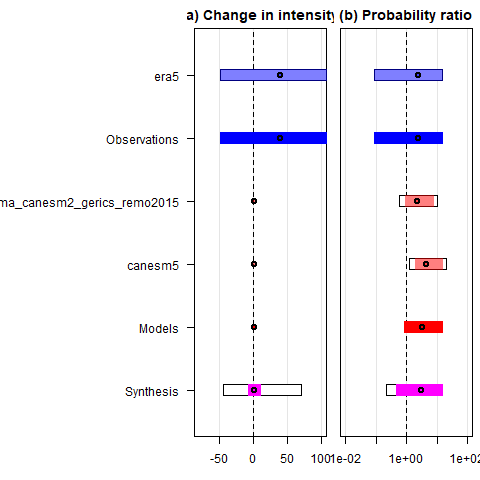

In [405]:
%%R
# put two figures next to each other
prep_window(prep_rc,
            h = prep_h,         # height of the figure (ins)
            w = prep_w,         # width of each panel (ins)
            res = prep_res,
            pch = prep_pch,
            oma = prep_oma,     # increase second number until model names fit in margin
            mar = prep_mar)     # shouldn't need to be changed

# set the x-axis (xlim) so that both the past & future changes use the same scaling
plot_synthesis(synth_dI_attr, lwd=12, add_space = F, main = "(a) Change in intensity", xlim = x_lim_dI)
plot_synthesis(synth_PR_attr, lwd=12, add_space = F, hide_labels = T, main = "(b) Probability ratio", xlim = x_lim_PR)

In [406]:
%%R
prep_rc = c(1, 2)
prep_h = 3
prep_w = 5
prep_res = 200
prep_pch = 20
prep_oma = c(0, 20, 0, 0)
prep_mar = c(3, .5, 2, .5)

x_lim_dI = c(0, 3)
x_lim_PR = c(1e-2, 1e2)

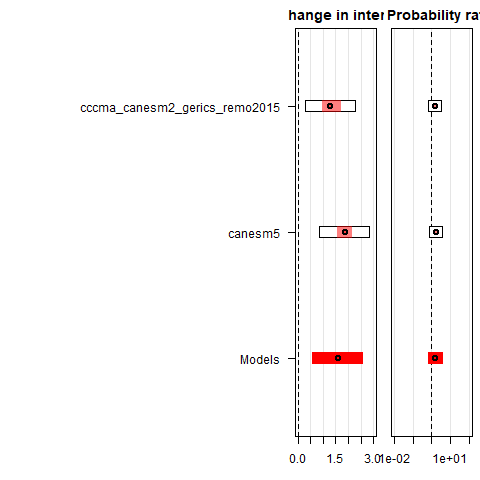

In [407]:
%%R
prep_window(prep_rc,
            h = prep_h,         # height of the figure (ins)
            w = prep_w,         # width of each panel (ins)
            res = prep_res,
            pch = prep_pch,
            oma = prep_oma,     # increase second number until model names fit in margin
            mar = prep_mar)     # shouldn't need to be changed

# set the x-axis (xlim) so that both the past & future changes use the same scaling
plot_synthesis(synth_dI_proj, lwd=12, add_space = F, main = "(a) Change in intensity", xlim = x_lim_dI)
plot_synthesis(synth_PR_proj, lwd=12, add_space = F, hide_labels = T, main = "(b) Probability ratio", xlim = x_lim_PR)

## Produce figures of the synthesis

In [408]:
%%R

attr_export_path <- file.path(your_save_directory, "synth-fig_attr.png")

png(attr_export_path, height = 360, width = 480*1.5); par(mfrow = c(1,2), oma = c(0,20,0,0), mar = c(3,0.5,2,0.5)); {
    # set the x-axis (xlim) so that both the past & future changes use the same scaling
    plot_synthesis(synth_dI_attr, add_space = F, main = "(a) Change in intensity", xlim = c(-2,8))
    plot_synthesis(synth_PR_attr, add_space = F, hide_labels = T, main = "(b) Probability ratio", xlim = c(1e-2, 1e8))
}; dev.off()

png 
  2 


In [409]:
%%R

proj_export_path <- file.path(your_save_directory, "synth-fig_proj.png")

png(proj_export_path, height = 240, width = 480*1.5); par(mfrow = c(1,2), oma = c(0,20,0,0), mar = c(3,0.5,2,0.5)); {
    # set the x-axis (xlim) so that both the past & future changes use the same scaling
    plot_synthesis(synth_dI_proj, add_space = F, main = "(a) Change in intensity", xlim = c(-2,8))
    plot_synthesis(synth_PR_proj, add_space = F, hide_labels = T, main = "(b) Probability ratio", xlim = c(1e-2, 1e8))
}; dev.off()

png 
  2 


In [410]:
%%R
# Cells below are for testing to produce table outputs

colnames(df_models)

 [1] "Include"           "eval_sigma0_est"   "eval_sigma0_lower"
 [4] "eval_sigma0_upper" "eval_shape_est"    "eval_shape_lower" 
 [7] "eval_shape_upper"  "rp_value"          "attr_PR_est"      
[10] "attr_PR_lower"     "attr_PR_upper"     "attr_dI.abs_est"  
[13] "attr_dI.abs_lower" "attr_dI.abs_upper" "attr_dI.rel_est"  
[16] "attr_dI.rel_lower" "attr_dI.rel_upper" "proj_PR_est"      
[19] "proj_PR_lower"     "proj_PR_upper"     "proj_dI.abs_est"  
[22] "proj_dI.abs_lower" "proj_dI.abs_upper" "proj_dI.rel_est"  
[25] "proj_dI.rel_lower" "proj_dI.rel_upper" "aic_eval"         
[28] "aic_attr"          "aic_proj"          "attr_nobs"        
[31] "attr_nsamp"        "attr_nfailed"      "proj_nobs"        
[34] "proj_nsamp"        "proj_nfailed"     


In [411]:
%%R

obs_cols <- colnames(df_obs)
model_cols <- colnames(df_models)

diff_cols <- setdiff(union(obs_cols, model_cols), intersect(obs_cols, model_cols))
diff_cols

 [1] "mu0_est"               "mu0_lower"             "mu0_upper"            
 [4] "sigma0_est"            "sigma0_lower"          "sigma0_upper"         
 [7] "alpha_gmst_est"        "alpha_gmst_lower"      "alpha_gmst_upper"     
[10] "shape_est"             "shape_lower"           "shape_upper"          
[13] "disp_est"              "disp_lower"            "disp_upper"           
[16] "event_magnitude_est"   "event_magnitude_lower" "event_magnitude_upper"
[19] "return_period_est"     "return_period_lower"   "return_period_upper"  
[22] "PR_est"                "PR_lower"              "PR_upper"             
[25] "dI_abs_est"            "dI_abs_lower"          "dI_abs_upper"         
[28] "dI_rel_est"            "dI_rel_lower"          "dI_rel_upper"         
[31] "aic_est"               "aic_lower"             "aic_upper"            
[34] "n_est"                 "n_lower"               "n_upper"              
[37] "Include"               "eval_sigma0_est"       "eval_sigma0_lower"    